In [96]:
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

## Fit reducer on pretraining data

In [75]:
df_dict = {
    db: pd.read_csv(f'../embeddings/{db}.csv',  index_col='name')
    for db in ['hMOF', 'UO', 'CoRE2019', 'Tobacco', 'hCOF', 'hPPN', 'hZEO']
}

for db, df in df_dict.items():
    df_dict[db]['Class'] = db
    
Xy = pd.concat(df_dict.values())

In [83]:
reducer = TSNE()
#reducer = PCA(random_state=42)
#pipe = Pipeline([('scaler', StandardScaler()), ('reducer', reducer)])
pipe = Pipeline([('scaler', 'passthrough'), ('reducer', reducer)])
reducer.set_output(transform='pandas')
Z = reducer.fit_transform(Xy.iloc[:, :128])

## Visualize embeddings

In [238]:
sns.set_theme(style='white')#, font_scale=1.2)
palette = sns.color_palette()

In [229]:
Zy = Z.copy()
Zy['Class'] = Xy.loc[Z.index, 'Class']

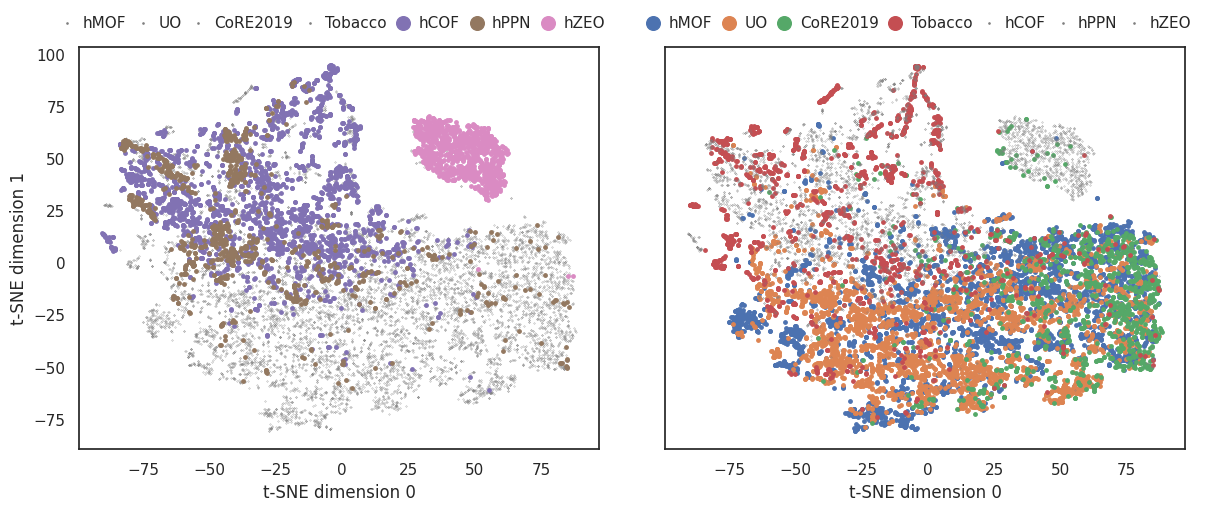

In [251]:
mofs = ['hMOF', 'UO', 'Tobacco', 'CoRE2019']

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=[12, 5], layout='constrained', sharey=True)

for i, cls in enumerate(Zy['Class'].unique()):
    subset = Zy[Zy['Class'] == cls]
    c, s = (palette[i], 6) if cls not in mofs else ('tab:gray', 0.05)
    ax1.scatter(subset.loc[:, 'tsne0'], subset.loc[:, 'tsne1'], label=cls, color=c, s=s)
    c, s = (palette[i], 6) if cls in mofs else ('tab:gray', 0.05)
    ax2.scatter(subset.loc[:, 'tsne0'], subset.loc[:, 'tsne1'], label=cls, color=c, s=s)

#ax.set_xlim(-95, 95)
#ax.set_ylim(-95, 95)


for ax in (ax1, ax2):
    ax.set_xlabel('t-SNE dimension 0')
    
ax1.set_ylabel('t-SNE dimension 1')

for ax in (ax1, ax2):
    ax.legend(
        loc='center', bbox_to_anchor=(0.48, 1.06),
        ncols=7, frameon=False, markerscale=4,
        columnspacing=0.1, handletextpad=0.01
    )

plt.savefig('figures/tsne.png', dpi=300)